# Experiment 1

## Imports

In [2]:
import torch
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
import json
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Datapipeline

In [4]:

def tokenize(sentence):

    words_ending_with_dot = ''.join([letter for letter in sentence.lower() if letter != '.'])
    tokens_ = [words for words in  words_ending_with_dot.split()]

    #remove numbers
    without_numbers = []
    for word in tokens_:
        if re.search(r'\d', word):
            pass
        else:
            without_numbers.append(word)


    # remove
    without_special_characters = []

    for word in without_numbers:
        if re.search(r'[^\w\s]', word):
            pass
        else:
            without_special_characters.append(word)

    # remove stopwords

    without_stopwords = []

    for word in without_special_characters:
        if word in stop_words:
            continue
        else:
            without_stopwords.append(word)

    return without_stopwords


loading class weights

In [5]:
try:
    import yaml
except:
    !pip install -q PyYAML
    import yaml

with open("/content/data_configs.yml", 'r') as f:
    config = yaml.safe_load(f)

class_weights = list(config['class_weights'].values())
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = class_weights.to(device)
class_weights

FileNotFoundError: [Errno 2] No such file or directory: '/content/data_configs.yml'

In [ ]:
def create_idx(tokens: list):
    ind = []
    for word in tokens:
        idx = vocab.get(word,vocab['<UNK>'])
        ind.append(idx)
    return ind

In [ ]:
vocab['<PAD>']

0

In [ ]:
vocab_size = len(vocab.values())
vocab_size

23868

In [ ]:
def pipeline(sentence):
    return create_idx(tokenize(sentence))


In [ ]:
import pandas as pd

class Data(torch.utils.data.Dataset):
    def __init__(self, path):
        df = pd.read_csv(path)
        self.text = df.text.tolist()
        self.label = df.category.tolist()
        self.labels = ['business', 'entertainment', 'politics', 'sport', 'tech']


    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        text = self.text[idx]
        indices = pipeline(text)

        label = self.label[idx]
        label = self.labels.index(label)

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

In [ ]:
BATCH_SIZE = 32

def collate_fn(batch):
    text, label = zip(*batch)
    length = torch.tensor([len(seq) for seq in text], dtype=torch.long)
    padded = torch.nn.utils.rnn.pad_sequence(text, batch_first=True, padding_value=vocab['<PAD>'])
    label = torch.tensor(label, dtype=torch.long)
    return padded,  length, label

train_ds = torch.utils.data.DataLoader(Data(r"/content/trian.csv"), batch_size=BATCH_SIZE, collate_fn=collate_fn)
txt, lengths, lbl = next(iter(train_ds))

print(f"{txt.shape}, {lengths.shape}, {lbl.shape}")
valid_ds = torch.utils.data.DataLoader(Data(r"/content/valid.csv"), batch_size=BATCH_SIZE, collate_fn=collate_fn)

torch.Size([32, 358]), torch.Size([32]), torch.Size([32])


## Training

In [ ]:
torch.manual_seed(42)
class ModelOne(torch.nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.emb = torch.nn.Embedding(vocab_size, emb_dim)
        self.lstm1 = torch.nn.LSTM(emb_dim, 32, num_layers=1, dropout=0.2, batch_first=True)
        self.fc1 = torch.nn.Linear(32, 5)

    def forward(self, x, lengths):
        z = self.emb(x)
        z = torch.nn.utils.rnn.pack_padded_sequence(z,lengths, batch_first=True, enforce_sorted=False)
        _, (h_,c_) = self.lstm1(z)
        z = self.fc1(h_[0])
        return z

model1 = ModelOne(vocab_size+2, 256)
model1.to(device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


ModelOne(
  (emb): Embedding(23870, 256)
  (lstm1): LSTM(256, 32, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=32, out_features=5, bias=True)
)

In [ ]:
try:
    from tqdm.quto import tqdm
except:
    !pip install -q tqdm
    from tqdm.auto import tqdm

def accuracy_fn(y_logits, y):
    y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    accuracy = torch.eq(y_pred, y).sum() / len(y)
    return accuracy



def train_step(model, train_ds, loss_fn, optimizer, epoch=1):

    train_loss = 0
    train_acc = 0

    progress_bar = tqdm(enumerate(train_ds), total=len(train_ds), desc="Training", leave=True)

    for batch,(x,l, y) in progress_bar:
        x,l,y = x.to(device),l, y.to(device)
        y_logits = model(x, l)
        loss = loss_fn(y_logits, y)
        acc = accuracy_fn(y_logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        progress_bar.set_description(f"EPOCH: {epoch+1} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")

        train_loss += loss
        train_acc += acc

    train_loss /= len(train_ds)
    train_acc /= len(train_ds)

    return train_loss, train_acc


def test_step(model, test_ds, loss_fn):
    test_loss = 0
    test_acc = 0

    model.eval()
    with torch.no_grad():
        for x,l,y in test_ds:
            x,l,y = x.to(device),l, y.to(device)
            test_logits = model(x,l)
            t_loss = loss_fn(test_logits, y)
            t_acc = accuracy_fn(test_logits, y)

            test_loss += t_loss
            test_acc += t_acc

    test_loss /= len(valid_ds)
    test_acc /= len(valid_ds)

    return test_loss, test_acc

In [ ]:
from pathlib import Path

LR = 5e-4
EPOCHS = 100

model_name1 = "model_lstm_1layer"
model_save_dir1 = Path(f"/content/drive/MyDrive/Models/news-categorisation/{model_name1}")
model_save_dir1.mkdir(exist_ok=True)

# weighted loss function
loss_fn1 = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer1 = torch.optim.NAdam(model1.parameters(), lr=LR)


train_accuracies = []
train_losses = []

test_accuracies = []
test_losses = []

best_val_loss = 0

for epoch in range(EPOCHS):
    model1.train()

    train_loss1, train_acc1 = train_step(model1, train_ds, loss_fn1, optimizer1, epoch=epoch)
    train_losses.append(train_loss1.detach().cpu().numpy())
    train_accuracies.append(train_acc1.detach().cpu().numpy())



    model1.eval()
    with torch.no_grad():
        test_loss1, test_acc1 = test_step(model1, valid_ds, loss_fn1)
        test_losses.append(test_loss1.detach().cpu().numpy())
        test_accuracies.append(test_acc1.detach().cpu().numpy())

    print(f"Train accuracy: {train_acc1:.4f} | Train loss: {train_loss1:.4f} | Test acc: {test_acc1:.4f} | Test loss: {test_loss1:.4f}")

    # saving best model
    if best_val_loss > test_loss1.detach().cpu().numpy():
        file_name1 = f"{model_name1}__{epoch+1}_epoch.pth"
        path1 = model_save_dir1 / file_name1
        torch.save(model1.state_dict(), path1)





Training:   0%|          | 0/58 [00:00<?, ?it/s]

Train accuracy: 0.2080 | Train loss: 1.6183 | Test acc: 0.3223 | Test loss: 1.5853


Training:   0%|          | 0/58 [00:00<?, ?it/s]

Train accuracy: 0.3324 | Train loss: 1.5577 | Test acc: 0.3733 | Test loss: 1.5629


Training:   0%|          | 0/58 [00:00<?, ?it/s]

...

Train accuracy: 1.0000 | Train loss: 0.0189 | Test acc: 0.7818 | Test loss: 0.7527


Training:   0%|          | 0/58 [00:00<?, ?it/s]

Train accuracy: 1.0000 | Train loss: 0.0163 | Test acc: 0.7818 | Test loss: 0.7578


Training:   0%|          | 0/58 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Evaluation

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

IMAGE_PATH = Path('/content/drive/MyDrive/Experiments/text-classification')
def save_fig(filename, tight_layout=True, save_format='jpg', resolution=300):
    path = IMAGE_PATH / f"01_added_stopwords/{filename}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=save_format, dpi=resolution)


<Axes: >

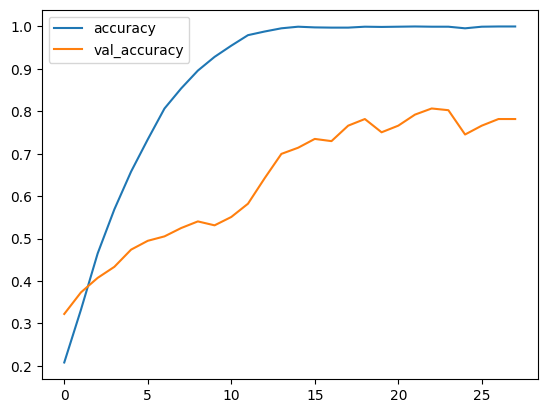

In [ ]:
import numpy as np
import pandas as pd
accuracies = pd.DataFrame({'accuracy':np.array(train_accuracies), 'val_accuracy':np.array(test_accuracies)})
accuracies.to_csv("/content/drive/MyDrive/Experiments/text-classification/exp_1_accuracy.csv", index=False)
accuracies.plot()

<Axes: >

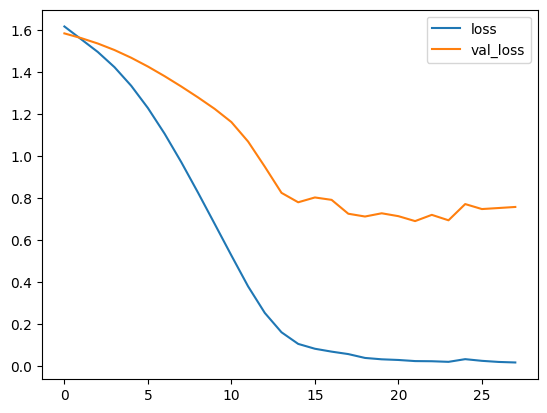

In [ ]:
losses = pd.DataFrame({'loss':np.array(train_losses), 'val_loss':np.array(test_losses)})
losses.to_csv("/content/drive/MyDrive/Experiments/text-classification/exp_1_loss.csv", index=False)
losses.plot()

In [ ]:

1 if 2.3 > torch.tensor(1.4).cpu().numpy() else 0

1

# Experiment No 2

## Imports

In [3]:
import torch
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [4]:
import pandas as pd

train_set = pd.read_csv(r"..\data\train.csv")
train_set.head(5)

,category,text
0,business,iraq to invite phone licence bids iraq is to i...
1,business,malaysia lifts islamic bank limit malaysia s c...
2,tech,hacker threat to apple s itunes users of apple...
3,business,brewers profits lose their fizz heineken and ...
4,entertainment,berlin cheers for anti-nazi film a german movi...


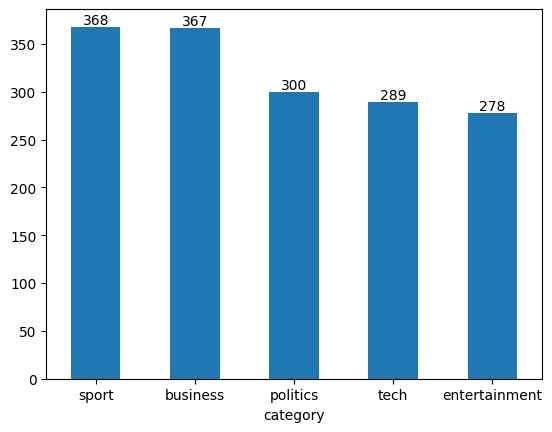

In [3]:
ax = train_set['category'].value_counts().plot.bar(rot=0)

for cont in ax.containers:
    ax.bar_label(cont)

In [4]:
try:
    from nltk.corpus import wordnet
    import nltk
except:
    !pip install -q nltk
    from nltk.corpus import wordnet
    import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\brian\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\brian\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Augmentation

In [6]:
import random
from tqdm import tqdm



def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(sentence, n=2):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if get_synonyms(word)]))
    random.shuffle(random_word_list)
    num_replaced = 0

    for word in random_word_list:
        synonyms = get_synonyms(word)
        if synonyms:
            synonym = random.choice(synonyms)
            new_words = [synonym if w == word else w for w in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return " ".join(new_words)


def balance_classes(df, target_count=368):
    classes = df['category'].unique()
    balanced_data = []

    for label in classes:
        class_df = df[df['category'] == label]
        current_count = len(class_df)
        balanced_data.append(class_df)

        if current_count < target_count:
            needed = target_count - current_count
            samples = class_df['text'].tolist()

            augmented_texts = []
            for i in range(needed):
                original_text = random.choice(samples)
                aug_text = synonym_replacement(original_text, n=2)
                augmented_texts.append([aug_text, label])

            aug_df = pd.DataFrame(augmented_texts, columns=['text', 'category'])
            balanced_data.append(aug_df)

    return pd.concat(balanced_data).reset_index(drop=True)



In [1]:
input_file = r"..\data\train.csv"   
output_file = r"..\data\augment.csv"

df = pd.read_csv(input_file)
print("Original class distribution:\n", df['category'].value_counts())

balanced_df = balance_classes(df, target_count=368)

print("New class distribution:\n", balanced_df['category'].value_counts())
balanced_df.to_csv(output_file, index=False)
print(f"Balanced dataset saved to: {output_file}")

NameError: name 'pd' is not defined

In [5]:
train_aug = pd.read_csv(r"..\data\augment.csv")
train_aug.head()

,category,text
0,business,iraq to invite phone licence bids iraq is to i...
1,business,malaysia lifts islamic bank limit malaysia s c...
2,business,brewers profits lose their fizz heineken and ...
3,business,aviation firms eye booming india india s defen...
4,business,peugeot deal boosts mitsubishi struggling japa...


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(train_aug["category"])
le.classes_

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype=object)

## Datapipeline2

In [6]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


def tokenize(sentence):
    words_ending_with_dot = ''.join([letter for letter in sentence.lower() if letter != '.'])
    tokens_ = [words for words in  words_ending_with_dot.split()]

    #remove numbers
    without_numbers = []
    for word in tokens_:
        if re.search(r'\d', word):
            pass
        else:
            without_numbers.append(word)


    # remove
    without_special_characters = []

    for word in without_numbers:
        if re.search(r'[^\w\s]', word):
            pass
        else:
            without_special_characters.append(word)

    # remove stopwords

    without_stopwords = []

    for word in without_special_characters:
        if word in stop_words:
            continue
        else:
            without_stopwords.append(word)

    return without_stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\brian\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
def get_vocab(unique_tokens):
    vocab = {token:i+2 for i,token in enumerate(unique_tokens)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

Create vocab

In [8]:
train_augmented = pd.read_csv(r"../data/augment.csv")
aug_txt = train_augmented['text'].tolist()

In [9]:
full_tokens = [tokenize(row) for row in aug_txt]
len(full_tokens)

1840

In [10]:
unique_tokens = set([token for row in full_tokens for token in row])
len(unique_tokens)

23998

In [11]:
vocab_size = len(unique_tokens)
vocab_size

23998

In [12]:
vocab = get_vocab(unique_tokens)
len(vocab)

24000

In [13]:
import json

with open("../configs/vocab.json", 'w') as f:
    json.dump(vocab,f)


In [21]:
vocab['<UNK>']

1

In [22]:
def create_idx(tokens: list):
    ind = []
    for word in tokens:
        idx = vocab.get(word,vocab['<UNK>'])
        ind.append(idx)
    return ind

def pipeline(sentence):
    return create_idx(tokenize(sentence))

In [23]:
class Data(torch.utils.data.Dataset):
    def __init__(self, path):
        df = pd.read_csv(path)
        self.text = df.text.tolist()
        self.label = df.category.tolist()
        self.labels = ['business', 'entertainment', 'politics', 'sport', 'tech']


    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        text = self.text[idx]
        indices = pipeline(text)

        label = self.label[idx]
        label = self.labels.index(label)

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)


def collate_fn(batch):
    text, label = zip(*batch)
    length = torch.tensor([len(seq) for seq in text], dtype=torch.long)
    padded = torch.nn.utils.rnn.pad_sequence(text, batch_first=True, padding_value=vocab['<PAD>'])
    label = torch.tensor(label, dtype=torch.long)
    return padded,  length, label


## Train

### Model

In [52]:
torch.manual_seed(42)
class ModelOne(torch.nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.emb = torch.nn.Embedding(vocab_size, emb_dim)
        self.lstm1 = torch.nn.LSTM(emb_dim, 16, num_layers=1,batch_first=True)
        self.fc1 = torch.nn.Linear(16, 5)
        self.dropout = torch.nn.Dropout(0.5)

    def forward(self, x, lengths):
        z = self.emb(x)
        z = torch.nn.utils.rnn.pack_padded_sequence(z,lengths, batch_first=True, enforce_sorted=False)
        _, (h_,c_) = self.lstm1(z)
        z = self.dropout(h_[0])
        z = self.fc1(z)
        return z

model2 = ModelOne(vocab_size+2, 256)
model2.to(device)

ModelOne(
  (emb): Embedding(24000, 256)
  (lstm1): LSTM(256, 16, batch_first=True)
  (fc1): Linear(in_features=16, out_features=5, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [26]:
try:
    from tqdm.quto import tqdm
except:
    !pip install -q tqdm
    from tqdm.auto import tqdm

def accuracy_fn(y_logits, y):
    y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    accuracy = torch.eq(y_pred, y).sum() / len(y)
    return accuracy



def train_step(model, train_ds, loss_fn, optimizer, epoch=1):

    train_loss = 0
    train_acc = 0

    progress_bar = tqdm(enumerate(train_ds), total=len(train_ds), desc="Training", leave=True)

    for batch,(x,l, y) in progress_bar:
        x,l,y = x.to(device),l, y.to(device)
        y_logits = model(x, l)
        loss = loss_fn(y_logits, y)
        acc = accuracy_fn(y_logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        progress_bar.set_description(f"EPOCH: {epoch+1} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")

        train_loss += loss
        train_acc += acc

    train_loss /= len(train_ds)
    train_acc /= len(train_ds)

    return train_loss, train_acc


def test_step(model, test_ds, loss_fn):
    test_loss = 0
    test_acc = 0

    model.eval()
    with torch.no_grad():
        for x,l,y in test_ds:
            x,l,y = x.to(device),l, y.to(device)
            test_logits = model(x,l)
            t_loss = loss_fn(test_logits, y)
            t_acc = accuracy_fn(test_logits, y)

            test_loss += t_loss
            test_acc += t_acc

    test_loss /= len(valid_ds)
    test_acc /= len(valid_ds)

    return test_loss, test_acc

### Training

In [53]:
from pathlib import Path
# Hyper params
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 32

train_data = Data(r"../data/augment.csv")
train_ds = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True, drop_last=True)
txt, lengths, lbl = next(iter(train_ds))

In [54]:
valid_data = Data(r"../data/test.csv")
valid_ds = torch.utils.data.DataLoader(valid_data, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
txt, lengths, lbl = next(iter(valid_ds))
print(f"{txt.shape}, {lengths.shape}, {lbl.shape}")


torch.Size([32, 410]), torch.Size([32]), torch.Size([32])


In [49]:
txt

tensor([[18793, 21463,  5056,  ...,     0,     0,     0],
        [    1, 12019,  6383,  ...,     0,     0,     0],
        [ 7189, 14423,  2573,  ...,     0,     0,     0],
        ...,
        [21874,  3278,  4319,  ...,     0,     0,     0],
        [21187, 15619, 14653,  ...,     0,     0,     0],
        [ 4441,  5873,  8276,  ...,     0,     0,     0]])

In [ ]:
model_name2 = "02_Experiment_LSTM"
model_save_dir2 = Path(f"../experiment_models/{model_name2}")
model_save_dir2.mkdir(exist_ok=True)

# weighted loss function
loss_fn2 = torch.nn.CrossEntropyLoss()
optimizer2 = torch.optim.NAdam(model2.parameters(), lr=LR, weight_decay=1e-3)


train_accuracies = []
train_losses = []

test_accuracies = []
test_losses = []

best_val_loss = 1

for epoch in range(EPOCHS):
    model2.train()

    train_loss2, train_acc2 = train_step(model2, train_ds, loss_fn2, optimizer2, epoch=epoch)
    train_losses.append(train_loss2.detach().cpu().numpy())
    train_accuracies.append(train_acc2.detach().cpu().numpy())

    model2.eval()
    with torch.no_grad():
        test_loss2, test_acc2 = test_step(model2, valid_ds, loss_fn2)
        test_losses.append(test_loss2.detach().cpu().numpy())
        test_accuracies.append(test_acc2.detach().cpu().numpy())

    print(f"Train accuracy: {train_acc2:.4f} | Train loss: {train_loss2:.4f} | Test acc: {test_acc2:.4f} | Test loss: {test_loss2:.4f}")


    file_name2 = f"{model_name2}__{epoch+1}_epoch.pth"
    path2 = model_save_dir2 / file_name2
    torch.save(model2.state_dict(), path2)
        


EPOCH: 1 | Loss: 1.5924 | Acc: 0.2812: 100%|██████████| 57/57 [00:21<00:00,  2.62it/s]


Train accuracy: 0.2242 | Train loss: 1.6311 | Test acc: 0.1976 | Test loss: 1.6213


EPOCH: 2 | Loss: 1.6479 | Acc: 0.2500: 100%|██████████| 57/57 [00:20<00:00,  2.74it/s]


Train accuracy: 0.2812 | Train loss: 1.5836 | Test acc: 0.2090 | Test loss: 1.6098


EPOCH: 3 | Loss: 1.4993 | Acc: 0.4375: 100%|██████████| 57/57 [00:20<00:00,  2.75it/s]


...

Train accuracy: 0.9896 | Train loss: 0.0748 | Test acc: 0.8969 | Test loss: 0.3982


EPOCH: 99 | Loss: 0.0842 | Acc: 0.9688: 100%|██████████| 57/57 [00:20<00:00,  2.85it/s]


Train accuracy: 0.9923 | Train loss: 0.0505 | Test acc: 0.8761 | Test loss: 0.5458


EPOCH: 100 | Loss: 0.0655 | Acc: 1.0000: 100%|██████████| 57/57 [00:15<00:00,  3.77it/s]


Train accuracy: 0.9879 | Train loss: 0.0593 | Test acc: 0.8718 | Test loss: 0.5051


## Evaluation

<Axes: ylabel='Accuracy'>

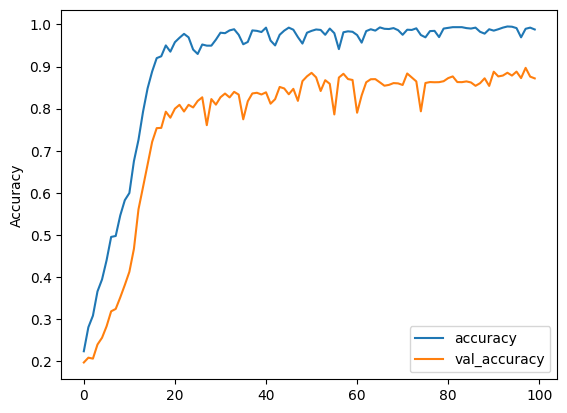

In [57]:
import numpy as np
import pandas as pd
accuracies = pd.DataFrame({'accuracy':np.array(train_accuracies), 'val_accuracy':np.array(test_accuracies)})
# accuracies.to_csv("/content/drive/MyDrive/Experiments/text-classification/02_experiment_accuracy.csv", index=False)
accuracies.plot(ylabel='Accuracy')

<Axes: ylabel='loss'>

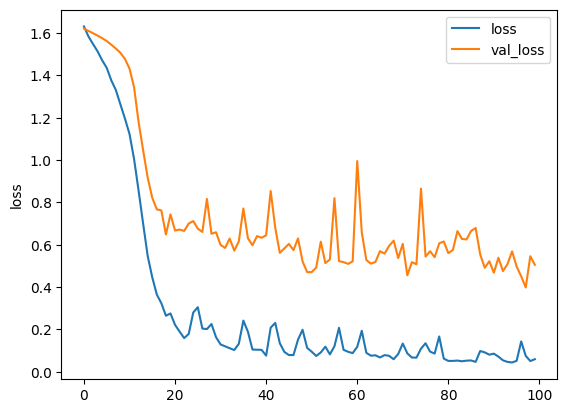

In [58]:
losses = pd.DataFrame({'loss':np.array(train_losses), 'val_loss':np.array(test_losses)})
# losses.to_csv("/content/drive/MyDrive/Experiments/text-classification/02_experiment_loss.csv", index=False)
losses.plot(ylabel='loss')